# 1. INTRODUCTION
<center>
<img src="https://cdn.pixabay.com/photo/2018/09/06/19/53/mushrooms-3659165_640.jpg" width=1300 height=750 />
</center>

**PROBLEM STATEMENT: Binary Prediction of Poisonous Mushrooms**

<font size="3">The original data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).  Each species is identified as definitely edible, definitely poisonous, or of unknown edibility and not recommended.  This latter class was combined with the poisonous one.  The Guide clearly states that there is no simple rule for determining the edibility of a mushroom; no rule like ``leaflets three, let it be'' for Poisonous Oak and Ivy. </font>

<font size="3">The link to the original dataset is [here](https://archive.ics.uci.edu/dataset/73/mushroom)</font>


**Metric of Evalutaion:** Matthews correlation coefficient

<center>
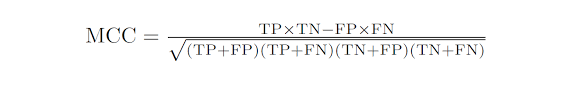
</center>

# 2. IMPORTS

In [ ]:
import sklearn
import numpy as np
from numba import njit, prange
import os
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import missingno as msno
from prettytable import PrettyTable
%matplotlib inline
import seaborn as sns
sns.set(style='darkgrid', font_scale=1.4)
from tqdm import tqdm
from tqdm.notebook import tqdm as tqdm_notebook
tqdm_notebook.get_lock().locks = []
# !pip install sweetviz
# import sweetviz as sv
import concurrent.futures
from copy import deepcopy       
from functools import partial
from itertools import combinations
import random
from random import randint, uniform
import gc
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler,PowerTransformer, FunctionTransformer
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from itertools import combinations
from sklearn.impute import SimpleImputer
import xgboost as xg
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import mean_squared_error,mean_squared_log_error, roc_auc_score, accuracy_score, f1_score, precision_recall_curve, log_loss
from sklearn.cluster import KMeans
!pip install yellowbrick
from yellowbrick.cluster import KElbowVisualizer
from scipy import stats
import statsmodels.api as sm
from scipy.stats import ttest_ind
from scipy.stats import boxcox
import math
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.base import BaseEstimator, TransformerMixin
# !pip install optuna
import optuna
!pip install cmaes
import cmaes
import xgboost as xgb
# !pip install catboost
# !pip install lightgbm --install-option=--gpu --install-option="--boost-root=C:/local/boost_1_69_0" --install-option="--boost-librarydir=C:/local/boost_1_69_0/lib64-msvc-14.1"
import lightgbm as lgb
# !pip install category_encoders
from category_encoders import OneHotEncoder, OrdinalEncoder, CountEncoder, CatBoostEncoder
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier,ExtraTreesClassifier, AdaBoostClassifier, HistGradientBoostingRegressor
# !pip install -U imbalanced-learn
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoost, CatBoostRegressor, CatBoostClassifier
from sklearn.svm import NuSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression, RidgeClassifierCV, LogisticRegressionCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from catboost import Pool
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD

import tensorflow

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option('display.max_columns',None)

## 2.1 DATA

In [ ]:
global device

gpus = tensorflow.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available")
    device = 'gpu'
else:
    print("GPU is not available")
    device = 'cpu'
    
n_samples_test=1000

train=pd.read_csv('/kaggle/input/playground-series-s4e8/train.csv')#[:n_samples_test]
test=pd.read_csv('/kaggle/input/playground-series-s4e8/test.csv')#[:n_samples_test]
submission=pd.read_csv("/kaggle/input/playground-series-s4e8/sample_submission.csv")#[:n_samples_test]

train.drop(columns=["id"],inplace=True)
test.drop(columns=["id"],inplace=True)

train_copy=train.copy()
test_copy=test.copy()

target='class'

train.head()

## 2.2 MISSING VALUES

In [ ]:
table = PrettyTable()

table.field_names = ['Feature', 'Data Type', 'Train Missing %', 'Test Missing %']
for column in train_copy.columns:
    data_type = str(train_copy[column].dtype)
    non_null_count_train= np.round(100-train_copy[column].count()/train_copy.shape[0]*100,1)
    if column!=target:
        non_null_count_test = np.round(100-test_copy[column].count()/test_copy.shape[0]*100,1)
    else:
        non_null_count_test="NA"
    table.add_row([column, data_type, non_null_count_train,non_null_count_test])
print(table)

<font size="3"> missing values are present in the data for categorical features</font>

# 3. EXPLORATORY DATA ANALYSIS

## 3.1 TARGET DISTRIBUTIONS

In [ ]:
def plot_pie_chart(data, target, title, ax):
    data_counts = data[target].value_counts()
    labels = data_counts.index
    sizes = data_counts.values
    colors = [(0.2, 0.7, 0.6), (0.8, 0.7, 0.3)]
    explode = [0.1] * len(labels)  # Create an explode list with the same length as the number of labels

    ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
    ax.axis('equal') 
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(9, 6))  # Create a single subplot with specified size

plot_pie_chart(train_copy, "class", "Target Distribution", ax)

plt.tight_layout()
plt.show()


## 3.2 CATEGORICAL FEATURE ANALYSIS

In [ ]:
cat_cols = [f for f in train.columns if (train[f].dtype != 'O' and train[f].nunique() <100) or (train[f].dtype == 'O' and f not in [target]) ]
custom_palette = (0.2, 0.7, 0.6), (0.8, 0.7, 0.3)
for col in cat_cols:
    contingency_table = pd.crosstab(train[col], train[target], normalize='index')
    sns.set(style="whitegrid")
    contingency_table.plot(kind="bar", stacked=True, color=custom_palette,figsize=(20, 4))
    plt.title(f"Percentage Distribution of Target across {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.legend(title="Target Class")
    plt.show()


<font size="3">Many categories have only one class, perhaps these can be clubbed as a new class</font>

In [ ]:

palette = [mcolors.to_rgba((0.2, 0.7, 0.6)), mcolors.to_rgba((0.8, 0.7, 0.3))]

cont_cols = [f for f in train.columns if train[f].dtype!='O' and f not in [target]]  

fig, axs = plt.subplots(nrows=len(cont_cols), figsize=(8, 4 * len(cont_cols)))
for i, col in enumerate(cont_cols):
    sns.boxplot(x=target, y=col, data=train, ax=axs[i], palette=palette)
    axs[i].set_title(f'{col.title()} vs Target', fontsize=16)
    axs[i].set_xlabel(target, fontsize=14)
    axs[i].set_ylabel(col.title(), fontsize=14)
    axs[i].tick_params(axis='both', labelsize=14)
    sns.despine()

fig.tight_layout()
plt.show()


<font size="3">Considerable outliers are involved and treatment could aid if NNs are incorporated in the later stages</font>

# 4. FEATURE ENGINEERING

### Basic Functions

In [ ]:
lgb_params = {
    'n_estimators': 50,
    'max_depth': 8,
    'learning_rate': 0.02,
    'subsample': 0.20,
    'colsample_bytree': 0.56,
    'reg_alpha': 0.25,
    'reg_lambda': 5e-08,
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'device':device.lower(),
    'verbose':-1
    }

def encode(y,target_map):
    '''
    To convert the outputs to numbers
    '''
    y=np.array(y)
    encoded_y=[target_map[f] for f in y]
    return encoded_y
def decode(y,target_map):
    '''To convert the predictions back to classes
    '''
    y=np.array(y)
    reverse_dict={v: k for k, v in target_map.items()}
    decoded_y=[reverse_dict[f] for f in y]
    return decoded_y
def min_max_scaler(train, test, column):
    '''
    Min Max just based on train might have an issue if test has extreme values, hence changing the denominator using overall min and max
    '''    
    max_val=max(train[column].max(),test[column].max())
    min_val=min(train[column].min(),test[column].min())

    train[column]=(train[column]-min_val)/(max_val-min_val)
    test[column]=(test[column]-min_val)/(max_val-min_val)
    
    return train,test  

hgbm_params={'learning_rate': 0.07590136944725749, 'max_depth': 6, 'min_samples_leaf': 12, 'max_leaf_nodes': 5}
lgb_params1 = {
            'n_estimators': 50,
            'max_depth': 6,
            "num_leaves": 16,
            'learning_rate': 0.002,
            'subsample': 0.7,
            'colsample_bytree': 0.8,
            #'reg_alpha': 0.25,
#             'reg_lambda': 5e-07,
            "boosting_type": "gbdt",    
            "objective":'regression_l1', 
            'metric': 'mean_absolute_error',
            'device': device.lower(),
            'random_state': 42,
            'verbose':-1
        }
def store_missing_rows(df, features):
    '''Function stores where missing values are located for given set of features'''
    missing_rows = {}
    
    for feature in features:
        missing_rows[feature] = df[df[feature].isnull()]
    
    return missing_rows
def fill_missing_numerical(train,test,target, max_iterations=10):
    '''Iterative Missing Imputer: Updates filled missing values iteratively using CatBoost Algorithm'''
    train_temp=train.copy()
    if target in train_temp.columns:
        train_temp=train_temp.drop(columns=target)
        
    
    df=pd.concat([train_temp,test],axis="rows")
    df=df.reset_index(drop=True)
    features=[ f for f in df.columns if df[f].isna().sum()>0]
    if len(features)>0:
        # Step 1: Store the instances with missing values in each feature
        missing_rows = store_missing_rows(df, features)

        # Step 2: Initially fill all missing values with "Missing"
        for f in features:
            df[f]=df[f].fillna(df[f].median())

        cat_features=[f for f in df.columns if not pd.api.types.is_numeric_dtype(df[f])]
        dictionary = {feature: [] for feature in features}

        for iteration in tqdm(range(max_iterations), desc="Iterations"):
            for feature in features:
#                 print(feature)
                # Skip features with no missing values
                rows_miss = missing_rows[feature].index
                replace_dict={}
                rev_replace_dict={}
                for col in  cat_features:
                    df[col]=df[col].astype(str)
                    int_cat=dict(zip(df[col].unique(),np.arange(0, df[col].nunique())))
                    rev_int_cat=dict(zip(np.arange(0, df[col].nunique()), df[col].unique()))
                    df[col]=df[col].replace(int_cat)
                
                    replace_dict[col]=int_cat
                    rev_replace_dict[col]=rev_int_cat

                missing_temp = df.loc[rows_miss].copy()
                non_missing_temp = df.drop(index=rows_miss).copy()
                y_pred_prev=missing_temp[feature]
                missing_temp = missing_temp.drop(columns=[feature])


                # Step 3: Use the remaining features to predict missing values using Random Forests
                X_train = non_missing_temp.drop(columns=[feature])
                y_train = non_missing_temp[[feature]]

                model1 =HistGradientBoostingRegressor(**hgbm_params, max_iter=100, loss="absolute_error", n_iter_no_change=50,random_state=42)
                model1.fit(X_train, y_train)
                
                model2 = lgb.LGBMRegressor(**lgb_params1)
                model2.fit(X_train, y_train) 
                
                # Step 4: Predict missing values for the feature and update all N features
                y_pred = (np.array(model1.predict(missing_temp))+np.array(model2.predict(missing_temp)))/2
                df.loc[rows_miss, feature] = y_pred
#                 error_minimize=rmse(y_pred,y_pred_prev) #mean_squared_error
                error_minimize=mean_squared_error(y_pred,y_pred_prev) #mean_squared_error
                dictionary[feature].append(error_minimize)  # Append the error_minimize value
                
                for col in  cat_features:
                    df[col]=df[col].replace(rev_int_cat)


        for feature, values in dictionary.items():
            values=np.array(values)/sum(values)
            iterations = range(1, len(values) + 1)  # x-axis values (iterations)
            plt.plot(iterations, values, label=feature)  # plot the values
            plt.xlabel('Iterations')
            plt.ylabel('RMSE')
            plt.title('Minimization of RMSE with iterations')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.show()
        train[features] = np.array(df.iloc[:train.shape[0]][features])
        test[features] = np.array(df.iloc[train.shape[0]:][features])

    return train,test

# 4.1 MISSING VALUES

In [ ]:

missing_cat=[f for f in train.columns if train[f].dtype=="O" and train[f].isna().sum()>0]
train_missing_pct = train[missing_cat].isnull().mean() * 100
test_missing_pct = test[missing_cat].isnull().mean() * 100

missing_pct_df = pd.concat([train_missing_pct, test_missing_pct], axis=1, keys=['Train %', 'Test%'])
print(missing_pct_df)

# 4.2 COUNT ENCODING

<font size="3">Clean up data points that are uncommon</font>

In [ ]:
%%time
cat_features=[f for f in test.columns if test[f].dtype=="O"]

print(train[cat_features].nunique())

for col in cat_cols:
  
    train[col]=train[col].astype(str)+"_"+col
    test[col]=test[col].astype(str)+"_"+col
    uncommon=list((set(test[col].unique())| set(train[col].unique()))-(set(test[col].unique())& set(train[col].unique())))
    train[col]=train[col].apply(lambda x: np.nan if x in uncommon else x)
    test[col]=test[col].apply(lambda x: np.nan if x in uncommon else x)
        
print(train[cat_features].nunique())

In [ ]:
def cat_encoding(train, test,cat_cols_updated, target):
    train_copy=train.copy()
    test_copy=test.copy()
    for feature in cat_cols_updated:

        dic = train[feature].value_counts().to_dict()
        train_copy[feature ] =train[feature].map(dic)
        test_copy[feature] = test[feature].map(dic)
        
    return train_copy, test_copy
train, test= cat_encoding(train, test,cat_features, target)

# 5. FEATURE SCALING

In [ ]:
final_features=[f for f in train.columns if f not in [target]]
final_features=[*set(final_features)]

sc=StandardScaler()

train_scaled=train.copy()
test_scaled=test.copy()
train_scaled[final_features]=sc.fit_transform(train[final_features])
test_scaled[final_features]=sc.transform(test[final_features])

missing=[f for f in test.columns if test[f].isna().sum()>0 or train[f].isna().sum()>0]

for f in missing:
    train_scaled[f]=train_scaled[f].fillna(0)
    test_scaled[f]=test_scaled[f].fillna(0)    

In [ ]:
train_scaled[target]=train_scaled[target].replace({'e':0,'p':1})
# train_scaled=train_scaled.drop_duplicates().reset_index(drop=True)
X_train = train_scaled.drop(columns=[target])
y_train = train_scaled[target]

X_test = test_scaled.copy()

del train_scaled, test_scaled, train, test

print(X_train.shape, X_test.shape)

# 6. CLASS WEIGHTS

In [ ]:

classes = np.unique(y_train)  # Get unique class labels
class_to_index = {cls: idx for idx, cls in enumerate(classes)}
y_train_numeric = np.array([class_to_index[cls] for cls in y_train])

class_counts = np.bincount(y_train_numeric)

total_samples = len(y_train_numeric)

class_weights = total_samples / (len(classes) * class_counts)

class_weights_dict = {cls: weight for cls, weight in zip(classes, class_weights)}

print("Class counts:", class_counts)
print("Total samples:", total_samples)
print("Class weights:", class_weights)
print("Class weights dictionary:", class_weights_dict)

# 7. MODELING

# 7.1 ANNs

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.layers import LeakyReLU, PReLU, ELU
from keras.layers import Dropout

from keras.utils import to_categorical

gpus = tensorflow.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available")
else:
    print("GPU is not available")
    
    
def optimizer():
    sgd=tensorflow.keras.optimizers.SGD(learning_rate=0.005, momentum=0.5, nesterov=True)
    rms = tensorflow.keras.optimizers.RMSprop()
    nadam=tensorflow.keras.optimizers.Nadam(
        learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07, name="Nadam"
    )
    adam=tensorflow.keras.optimizers.Adam()
    adamW = keras.optimizers.AdamW(learning_rate=0.002,weight_decay=0.001, beta_1=0.9, beta_2=0.999)
    
    return sgd,rms,nadam, adamW,adam


lrelu = lambda x: tensorflow.keras.activations.relu(x, alpha=0.1)

from tensorflow.keras import backend as K

def root_mean_squared_log_error(y_true, y_pred):
    '''
    Compute RMSLE between actuals & predictions
    '''
    return K.sqrt(K.mean(K.square(K.log(abs(y_pred+1)) - K.log(abs(y_true+1)))))
    
def root_mean_squared_error(y_true, y_pred):
    '''
    Compute RMSE between actuals & predictions
    '''
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

# Custom metric for MCC
def matthews_correlation_coefficient(y_true, y_pred):
    '''
    Compute MCC between actuals & predictions
    '''
    y_pred = tensorflow.round(y_pred)  # Round the predicted values to 0 or 1
    y_true = tensorflow.cast(y_true, tensorflow.int32)
    y_pred = tensorflow.cast(y_pred, tensorflow.int32)
    
    # Compute confusion matrix elements
    tp = tensorflow.reduce_sum(tensorflow.cast(y_true * y_pred, tensorflow.float32))
    tn = tensorflow.reduce_sum(tensorflow.cast((1 - y_true) * (1 - y_pred), tensorflow.float32))
    fp = tensorflow.reduce_sum(tensorflow.cast((1 - y_true) * y_pred, tensorflow.float32))
    fn = tensorflow.reduce_sum(tensorflow.cast(y_true * (1 - y_pred), tensorflow.float32))
    
    numerator = tp * tn - fp * fn
    denominator = tensorflow.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    
    return tensorflow.where(denominator == 0, 0.0, numerator / denominator)

In [ ]:
def init_ann1(num_classes, input_dim):
    '''
    Initialize the artificial neural network (ANN) for multiclass classification
    '''

    sgd, rms, nadam, adamW, adam = optimizer()
    
    ann = Sequential()
    ann.add(Dense(288, input_dim=input_dim, kernel_initializer='he_uniform', activation='relu'))
    ann.add(Dropout(0.4))
    ann.add(Dense(80, kernel_initializer='he_uniform', activation='relu'))
    ann.add(Dropout(0.1))
    ann.add(Dense(32, kernel_initializer='he_uniform', activation='relu'))
    ann.add(Dropout(0.0))
    
    # Change the output layer to match the number of classes
    ann.add(Dense(num_classes, kernel_initializer='he_uniform', activation='sigmoid'))
    
    # Compile the model with categorical_crossentropy loss and accuracy metric
    ann.compile(loss='binary_crossentropy', optimizer=nadam, metrics=[matthews_correlation_coefficient])
    
    return ann
def init_ann2(num_classes, input_dim):  
    sgd,rms,nadam, adamW, adam=optimizer()
    ann2 = Sequential()
    ann2.add(Dense(128, input_dim=X_test.shape[1], kernel_initializer='he_uniform', activation='relu'))
    ann2.add(Dropout(0.3))
    ann2.add(Dense(52,  kernel_initializer='he_uniform', activation='relu'))
    ann2.add(Dropout(0.1))
    ann2.add(Dense(12,  kernel_initializer='he_uniform', activation='relu'))
    ann2.add(Dropout(0.2))
#     ann2.add(Dense(16,  kernel_initializer='he_uniform', activation='relu'))
#     ann2.add(Dropout(0.1))

    ann2.add(Dense(num_classes, kernel_initializer='he_uniform', activation='sigmoid'))
    ann2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy',matthews_correlation_coefficient])
    
    return ann2

def init_ann3(num_classes, input_dim):
    sgd,rms,nadam, adamW, adam=optimizer()
    ann3 = Sequential()
    ann3.add(Dense(384, input_dim=X_test.shape[1], kernel_initializer='he_uniform', activation='relu'))
    ann3.add(Dropout(0.3))
    ann3.add(Dense(84,  kernel_initializer='he_uniform', activation='relu'))
    ann3.add(Dropout(0.0))
#     ann3.add(Dense(112,  kernel_initializer='he_uniform', activation='relu'))
#     ann3.add(Dropout(0.1))
#     ann3.add(Dense(4,  kernel_initializer='he_uniform', activation='relu'))
#     ann3.add(Dropout(0.1))

    ann3.add(Dense(num_classes, kernel_initializer='he_uniform', activation='sigmoid'))
    ann3.compile(loss='binary_crossentropy', optimizer=adamW, metrics=['accuracy',matthews_correlation_coefficient])
    
    return ann3

def init_ann4(num_classes, input_dim):
    sgd,rms,nadam, adamW, adam=optimizer()
    ann4 = Sequential()
    ann4.add(Dense(128, input_dim=X_test.shape[1], kernel_initializer='he_uniform', activation='relu'))
    ann4.add(Dropout(0.5))
    ann4.add(Dense(16,  kernel_initializer='he_uniform', activation='relu'))
    ann4.add(Dropout(0.3))
    # ann4.add(Dense(32,  kernel_initializer='he_uniform', activation='relu'))
    # ann4.add(Dropout(0.3))
    ann4.add(Dense(4,  kernel_initializer='he_uniform', activation='relu'))
    ann4.add(Dropout(0.1))

    ann4.add(Dense(num_classes, kernel_initializer='he_uniform', activation='sigmoid'))
    ann4.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy',matthews_correlation_coefficient])
    return ann4 

def init_ann5(num_classes, input_dim):
    sgd,rms,nadam, adamW, adam=optimizer()
    ann5 = Sequential()
    ann5.add(Dense(96, input_dim=X_test.shape[1], kernel_initializer='he_uniform', activation='relu'))
    ann5.add(Dropout(0.4))
    ann5.add(Dense(180,  kernel_initializer='he_uniform', activation='relu'))
#     ann5.add(Dropout(0.1))

    ann5.add(Dense(num_classes, kernel_initializer='he_uniform', activation='sigmoid'))
    ann5.compile(loss='binary_crossentropy', optimizer=rms, metrics=['accuracy',matthews_correlation_coefficient])
    return ann5

# 7.2 MODELS

In [ ]:
class Splitter:
    def __init__(self, test_size=0.2, kfold=True, n_splits=5):
        self.test_size = test_size
        self.kfold = kfold
        self.n_splits = n_splits

    def split_data(self, X, y, random_state_list):
        if self.kfold:
            for random_state in random_state_list:
                kf = StratifiedKFold(n_splits=self.n_splits, random_state=random_state, shuffle=True)
                for train_index, val_index in kf.split(X, y):
                    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
                    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
                    yield X_train, X_val, y_train, y_val

class Classifier:
    def __init__(self, n_estimators=100, device="cpu", random_state=0):
        self.n_estimators = n_estimators
        self.device = device
        self.random_state = random_state
        self.models = self._define_model()
        self.len_models = len(self.models)
        
    def _define_model(self):
        
        xgb_params = {
            'n_estimators': self.n_estimators,
            'learning_rate': 0.05,
            'max_depth': 4,
            'subsample': 0.8,
            'colsample_bytree': 0.1,
            'n_jobs': -1,
            'eval_metric': 'logloss',
            'objective': 'binary:logistic',
            'tree_method': 'hist',
            'verbosity': 0,
            'random_state': self.random_state,
            'class_weight':class_weights_dict,
        }
        if self.device == 'gpu':
            xgb_params['tree_method'] = 'gpu_hist'
            xgb_params['predictor'] = 'gpu_predictor'

        xgb_params2 = {
            'n_estimators': self.n_estimators,
            'gamma': 0.2785290882258914,
            'max_depth': 10,
            'subsample': 0.32478148672785395,
             'min_child_weight': 9,
            'colsample_bytree': 0.4867041443764002,
            'learning_rate': 0.0521164563894605,
            'reg_lambda': 0.0006976301054985199,
            'reg_alpha': 0.37133730627394207,
            'n_jobs': -1,
            'eval_metric': 'auc',
            'objective': 'binary:logistic',
            'tree_method': 'hist',
            'verbosity': 0,
            'random_state': self.random_state,
            'class_weight':class_weights_dict,
        }
        if self.device == 'gpu':
            xgb_params2['tree_method'] = 'gpu_hist'
            xgb_params2['predictor'] = 'gpu_predictor'
        

        xgb_params3 = {
            'n_estimators': self.n_estimators,
            'gamma': 0.49397719491406067, 
            'max_depth': 3, 
            'subsample': 0.9673369122717441, 
            'min_child_weight': 14, 
            'colsample_bytree': 0.5584701705560252, 
            'learning_rate': 0.09641407999069004, 
            'reg_lambda': 0.42311681612703594, 
            'reg_alpha': 0.9378987801469202,
            'n_jobs': -1,
            'eval_metric': 'auc',
            'objective': 'binary:logistic',
            'tree_method': 'hist',
            'verbosity': 0,
            'booster': 'gbtree',
            'random_state': self.random_state,
        }
        if self.device == 'gpu':
            xgb_params3['tree_method'] = 'gpu_hist'
            xgb_params3['predictor'] = 'gpu_predictor'
        xgb_params4 = {
            'n_estimators': self.n_estimators,
            'gamma': 0.7727496366669099, 
            'max_depth': 5, 
            'subsample': 0.9271110403141944, 
            'min_child_weight': 12, 
            'colsample_bytree': 0.3027150407438401, 
            'learning_rate': 0.062300330343445516, 
            'reg_lambda': 1.7011708519768575e-05, 
            'reg_alpha': 0.8392480113208207,
            'n_jobs': -1,
            'eval_metric': 'auc',
            'objective': 'binary:logistic',
            'tree_method': 'hist',
            'verbosity': 0,
            'booster': 'gbtree',
            'random_state': self.random_state,
        }
        if self.device == 'gpu':
            xgb_params4['tree_method'] = 'gpu_hist'
            xgb_params4['predictor'] = 'gpu_predictor'
        xgb_params5={
            "colsample_bylevel": 0.9268202748354142,
            "colsample_bynode": 0.9584021138317574,
            "colsample_bytree": 0.5015612007146208,
            "enable_categorical": True,
            "gamma": 0.3707206931090372,
            "grow_policy": "lossguide",
            "learning_rate": 0.02466371136439142,
            "max_depth": 21,
            "min_child_weight": 0.6117236350232369,
            "n_estimators": 5000,
            "n_jobs": -1,
            "random_state":  self.random_state,
            "reg_alpha": 1.7264475728199302,
            "reg_lambda": 94.37990118781973,
            "subsample": 0.7599216762241778,
            "tree_method": "hist",
            "verbosity": 0
        }
        if self.device == 'gpu':
            xgb_params5['tree_method'] = 'gpu_hist'
            xgb_params5['predictor'] = 'gpu_predictor'
       
        lgb_params = {
            'colsample_bytree': 0.5682206083486204,
            'learning_rate': 0.03663461240141722,
            'min_child_samples': 81,
            'min_child_weight': 0.02679654577764235,
            'n_estimators': 200,
            'n_jobs': -1,
            'num_leaves': 528,
            'lambda_l1': 1.2839313094233695,
            'lambda_l2': 0.020852490623379794,
            'subsample': 0.5625905664875526,
            'objective': 'binary',
#             'metric': 'auc',
            'boosting_type': 'gbdt',
            'device': self.device,
            'random_state': self.random_state,
#             'class_weight':class_weights_dict,
            'verbose':-1
        }

        lgb_params2 = {
            'n_estimators': 200,
            'max_depth': 9, 
            'min_samples_leaf': 80, 
            'subsample': 0.9860008289418009,
            'learning_rate': 0.04385296045764687, 
            'lambda_l1': 5.9332606376875505, 
            'lambda_l2': 1.4056952398920893e-05, 
            'colsample_bytree': 0.634257516675335,
            'objective': 'binary',
            'metric': 'auc',
            'boosting_type': 'gbdt',
            'device': self.device,
            'random_state': self.random_state,
            'verbose':-1
        }

        lgb_params3 = {
            'n_estimators': 200,
            'max_depth': 9, 
            'subsample': 0.5396835462409598, 
            'learning_rate': 0.049047285930431804, 
            'lambda_l1': 1.7490663112850725e-08, 
            'lambda_l2': 3.837216667252457, 
            'colsample_bytree': 0.3193726625999373,
            'objective': 'binary',
            'metric': 'f1',
            'boosting_type': 'gbdt',
            'device': self.device,
            'random_state': self.random_state,
            'verbose':-1
        }
        lgb_params4=lgb_params2.copy()  
        lgb_params4['subsample']=0.9
        lgb_params4['reg_lambda']=0.8762427869944874
        lgb_params4['reg_alpha']=0.31889688644219183
        lgb_params4['max_depth']=9
        lgb_params4['learning_rate']=0.107
        lgb_params4['colsample_bytree']=0.1
        
        lgb_params5=lgb_params2.copy()  
        lgb_params5['subsample']=0.9
        lgb_params5['reg_lambda']=0.5119821036432592
        lgb_params5['reg_alpha']=0.8978283976480275
        lgb_params5['max_depth']=11
        lgb_params5['learning_rate']=0.081
        lgb_params5['colsample_bytree']=0.1
        cb_params = {
            'iterations': self.n_estimators,
            'depth': 6,
            'learning_rate': 0.05,
            'l2_leaf_reg': 0.7,
            'random_strength': 0.2,
            'max_bin': 200,
            'od_wait': 65,
            'one_hot_max_size': 70,
            'grow_policy': 'Depthwise',
            'bootstrap_type': 'Bayesian',
            'od_type': 'Iter',
            'eval_metric': 'AUC',
            'loss_function': 'Logloss',
            'task_type': self.device.upper(),
            'random_state': self.random_state,
            'verbose':-1

        }
        cb_sym_params = cb_params.copy()
        cb_sym_params['grow_policy'] = 'SymmetricTree'
        cb_loss_params = cb_params.copy()
        cb_loss_params['grow_policy'] = 'Lossguide'

        cb_params2=  cb_params.copy()
        cb_params2['learning_rate']=0.019000000000000003
        cb_params2['depth']=9
        cb_params2['random_strength']=0.3
        cb_params2['one_hot_max_size']=10
        cb_params2['max_bin']=100
        cb_params2['l2_leaf_reg']=0.4189770851283918
#         cb_params2['bootstrap_type']='Bernoulli'

        cb_params3={
            'iterations': self.n_estimators,
            'random_strength': 0.1, 
            'one_hot_max_size': 70, 'max_bin': 100, 
            'learning_rate': 0.008, 
            'l2_leaf_reg': 0.3, 
            'grow_policy': 'Depthwise', 
            'depth': 9, 
            'max_bin': 200,
            'od_wait': 65,
            'bootstrap_type': 'Bayesian',
            'od_type': 'Iter',
            'eval_metric': 'TotalF1',
            'loss_function': 'Logloss',
            'task_type': self.device.upper(),
            'random_state': self.random_state,
        }
        cb_params4=  cb_params.copy()
        cb_params4['learning_rate']=0.14300000000000002
        cb_params4['depth']=16
        cb_params4['random_strength']=0.5959959004533222
        cb_params4['one_hot_max_size']=100
        cb_params4['max_bin']=150
        cb_params4['l2_leaf_reg']=0.3838383515991557
        cb_params4['grow_policy']='Lossguide'
        
        dt_params= {'criterion': 'gini', 'max_depth': 9, 'min_samples_split': 17, 'min_samples_leaf': 18, 'max_features': 0.8433062331953287}
        etr_params= {'criterion': 'gini', 'max_depth': 16, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 0.6678697051089325, 'bootstrap': True}
        hist_params= {'learning_rate': 0.05835392348975443, 'n_iter_no_change': 795, 'max_depth': 4, 'min_samples_leaf': 17, 'max_leaf_nodes': 98, 'l2_regularization': 1.923251027172902e-07}
        rf_params={'max_depth': 16, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 0.4156475826924276}
        gbt_params={'learning_rate': 0.13640097404424165, 'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 15, 'subsample': 0.8858460576511749, 'max_features': 0.6114927460685724}
        knn_params={'n_neighbors': 16, 'weights': 'uniform', 'p': 2, 'leaf_size': 13, 'algorithm': 'ball_tree'}
        adb_params={'n_estimators': 957, 'learning_rate': 0.6625214812098597}
        
        models = {
###########             'svc': SVC(gamma="auto", probability=True, random_state=self.random_state),
            'xgb':  xgb.XGBClassifier(**xgb_params),
#             'xgb2': xgb.XGBClassifier(**xgb_params2),
#             'xgb3': xgb.XGBClassifier(**xgb_params3),
#             'xgb4': xgb.XGBClassifier(**xgb_params4),
#             'xgb5': xgb.XGBClassifier(**xgb_params5),
           'lgb':  lgb.LGBMClassifier(**lgb_params),
#             'lgb2': lgb.LGBMClassifier(**lgb_params2),
#             'lgb3': lgb.LGBMClassifier(**lgb_params3),
#             'lgb4': lgb.LGBMClassifier(**lgb_params4),
#            'lgb5': lgb.LGBMClassifier(**lgb_params5),
#             'cat':  CatBoostClassifier(**cb_params),
#             'cat2': CatBoostClassifier(**cb_params2),
#             'cat3': CatBoostClassifier(**cb_params3),
#             'cat4': CatBoostClassifier(**cb_params4),
#             "cat_sym": CatBoostClassifier(**cb_sym_params),
            "cat_loss": CatBoostClassifier(**cb_loss_params),
#             'brf': BalancedRandomForestClassifier(n_estimators=4000,max_depth=12 ,n_jobs=-1, random_state=self.random_state),
#             'rf': RandomForestClassifier(n_estimators=250,**rf_params, random_state=self.random_state),
            'hist_gbm' : HistGradientBoostingClassifier(max_iter=self.n_estimators,**hist_params,class_weight=class_weights_dict, random_state=self.random_state),
#             'gbdt': GradientBoostingClassifier(**gbt_params,n_estimators=100,random_state=self.random_state),            
#             'ada': AdaBoostClassifier (**adb_params,random_state=self.random_state),
#             'etr': ExtraTreesClassifier(**etr_params,random_state=self.random_state),
#             'dt' : DecisionTreeClassifier(**dt_params,random_state=self.random_state),
# #             'knn': KNeighborsClassifier(**knn_params),
#             'log_reg': LogisticRegression(multi_class = 'ovr', max_iter = 1000),
#             'ridge': CalibratedClassifierCV(RidgeClassifierCV(alphas=100.02351202464449), method='sigmoid'),
#             'elasticNet':LogisticRegressionCV(Cs= [0.04426763148249415], l1_ratios= [0.9771433916131904]),
#             'ann1':init_ann1(1, X_test.shape[1]),
#             'ann2':init_ann2(1, X_test.shape[1]),
#             'ann3':init_ann3(1, X_test.shape[1]),
#             'ann4':init_ann4(1, X_test.shape[1]),
#             'ann5':init_ann5(1, X_test.shape[1]),

                                       
        }
        return models

# 7.3 WEIGHTED LINEAR ENSEMBLING

In [ ]:
class OptunaWeights:
    def __init__(self, random_state, n_trials=1000):
        self.study = None
        self.weights = None
        self.random_state = random_state
        self.n_trials = n_trials

    @staticmethod
    @njit
    def weighted_predictions(weights, y_preds):
        weighted_sum = np.zeros(y_preds.shape[1])
        for i in range(len(weights)):
            weighted_sum += weights[i] * y_preds[i]
        weighted_pred = weighted_sum / np.sum(weights)
        return np.clip(weighted_pred, 1e-15, 1 - 1e-15)

    def _objective(self, trial, y_true, y_preds):
        weights = np.array([trial.suggest_float(f"weight{n}", 1e-6, 1) for n in range(len(y_preds))])
        weighted_pred = self.weighted_predictions(weights, y_preds)
        
        auc_score = roc_auc_score(y_true, weighted_pred)
        log_loss_score = log_loss(y_true, weighted_pred)
        
#         if trial.number >0.95*self.n_trials:
#             threshold=find_best_threshold(y_true, weighted_pred)
#             weighted_pred=(weighted_pred >= threshold).astype(int)
#             mcc_score=matthews_corrcoef(y_true, weighted_pred)
#             return mcc_score
#         else:
            
        return auc_score/log_loss_score

    def fit(self, y_true, y_preds):
        y_preds = np.array(y_preds)  # Ensure y_preds is a NumPy array
        optuna.logging.set_verbosity(optuna.logging.ERROR)
        sampler = optuna.samplers.CmaEsSampler(seed=self.random_state)
        pruner = optuna.pruners.HyperbandPruner()
        self.study = optuna.create_study(sampler=sampler, pruner=pruner, study_name="OptunaWeights", direction='maximize')
        objective_partial = partial(self._objective, y_true=y_true, y_preds=y_preds)
        self.study.optimize(objective_partial, n_trials=self.n_trials, n_jobs=-1)
        self.weights = np.array([self.study.best_params[f"weight{n}"] for n in range(len(y_preds))])

    def predict(self, y_preds):
        assert self.weights is not None, 'OptunaWeights error: must be fitted before predict'
        y_preds = np.array(y_preds)  # Ensure y_preds is a NumPy array
        return self.weighted_predictions(self.weights, y_preds)

    def fit_predict(self, y_true, y_preds):
        self.fit(y_true, y_preds)
        return self.predict(y_preds)

    def get_weights(self):
        return self.weights


from scipy.optimize import minimize_scalar
from sklearn.metrics import matthews_corrcoef

def find_best_threshold(y_true, y_pred_probabilities):
    """
    Finds the best threshold that maximizes the MCC score using an optimization method.

    Args:
        y_true (array-like): The true labels.
        y_pred_probabilities (array-like): The predicted probabilities.

    Returns:
        float: The best threshold value.
    """
    # Define the objective function to minimize (negative MCC since we want to maximize MCC)
    def objective(threshold):
        y_pred = (y_pred_probabilities >= threshold).astype(int)
        return -matthews_corrcoef(y_true, y_pred)
    
    # Use minimize_scalar with bounds between 0 and 1
    result = minimize_scalar(objective, bounds=(0, 1), method='bounded')
    
    return result.x


# 7.4 MODEL FIT

In [ ]:
%%time
import time, warnings
warnings.filterwarnings('ignore')

kfold = True
n_splits = 1 if not kfold else 5
random_state = 42
random_state_list = [42] 
n_estimators = 999 
early_stopping_rounds = 300
verbose = False
splitter = Splitter(kfold=kfold, n_splits=n_splits)

# Initialize an array for storing test predictions
test_predss = np.zeros((X_test.shape[0]))
oof_predss = pd.DataFrame(np.zeros((X_train.shape[0], 1)))
ensemble_score = []
ensemble_acc_score = []
weights = []
trained_models = {'xgb':[]}
thresholds=[]
    
for i, (X_train_, X_val, y_train_, y_val) in enumerate(splitter.split_data(X_train, y_train, random_state_list=random_state_list)):
    n = i % n_splits
    m = i // n_splits
            
    # Get a set of Regressor models
    classifier = Classifier(n_estimators, device, random_state)
    models = classifier.models
    
    # Initialize lists to store oof and test predictions for each base model
    oof_preds = []
    test_preds = []
    start_time_fold = time.time()
    
    # Loop over each base model and fit it to the training data, evaluate on validation data, and store predictions
    for name, model in models.items():
        start_time = time.time()
        if ('cat' in name) or ("lgb" in name) or ("xgb" in name):
            if 'lgb' in name: #categorical_feature=cat_features
                model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)])
            elif 'cat' ==name:
                model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)],#cat_features=cat_features,
                          early_stopping_rounds=early_stopping_rounds, verbose=verbose)
            else:
                model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)], early_stopping_rounds=early_stopping_rounds, verbose=verbose)
        elif name in 'ann':
            model.fit(X_train_, y_train_, validation_data=(X_val, y_val),batch_size=4, epochs=5,verbose=verbose)
        else:
            model.fit(X_train_, y_train_)
        
        if 'ann' in name:
            test_pred = np.array(model.predict(X_test))[:, 0]
            y_val_pred = np.array(model.predict(X_val))[:, 0]
        else:
            test_pred = model.predict_proba(X_test)[:, 1]
            y_val_pred = model.predict_proba(X_val)[:, 1]
        
        end_time = time.time()
        time_taken = end_time - start_time
        
        
        threshold=find_best_threshold(y_val.to_numpy(), y_val_pred)
        y_val_pred_score=(y_val_pred >= threshold).astype(int)
        mcc_score=matthews_corrcoef(y_val, y_val_pred_score)
        print(f'{name} [FOLD-{n} SEED-{random_state_list[m]}] MCC Score: {mcc_score:.5f}, time taken :{time_taken:.3f} secs')
        
        oof_preds.append(y_val_pred)
        test_preds.append(test_pred)
        
        if name in trained_models.keys():
            trained_models[f'{name}'].append(deepcopy(model))
            
    # Use Optuna to find the best ensemble weights
    optweights = OptunaWeights(random_state=random_state)
    y_val_pred = optweights.fit_predict(y_val.to_numpy(), oof_preds)
    
    oof_predss.loc[y_val.index] = np.array(y_val_pred).reshape(-1, 1)
    
    threshold=find_best_threshold(y_val.to_numpy(), y_val_pred)
    thresholds.append(threshold)
    y_val_pred= (y_val_pred >= threshold).astype(int)
    mcc_score=matthews_corrcoef(y_val, y_val_pred)
        
    end_time_fold = time.time()
    time_taken = end_time_fold - start_time_fold
    
    print(f'Ensemble [FOLD-{n} SEED-{random_state_list[m]}] -------------------> MCC: {mcc_score:.5f}, fold time taken :{time_taken:.5f} secs')
    
    ensemble_score.append(mcc_score)
    weights.append(optweights.weights)
    
    # Predict to X_test by the best ensemble weights
    _test_preds = optweights.predict(test_preds)
    test_predss += _test_preds / (n_splits * len(random_state_list))
    
    del X_train_, X_val, y_train_, y_val
    
    gc.collect()

In [ ]:
# Calculate the mean ROC AUC  score of the ensemble
mean_score = np.mean(ensemble_score)
std_score = np.std(ensemble_score)
print(f'Ensemble MCC score {mean_score:.5f} ± {std_score:.5f}')

# Print the mean and standard deviation of the ensemble weights for each model
print('--- Model Weights ---')
mean_weights = np.mean(weights, axis=0)
std_weights = np.std(weights, axis=0)
for name, mean_weight, std_weight in zip(models.keys(), mean_weights, std_weights):
    print(f'{name}: {mean_weight:.5f} ± {std_weight:.5f}')

# 7.5 SUBMISSION

In [ ]:
oof_predss.to_csv('oof_predss_v5.csv',index=False)

submission[target]=test_predss
submission.to_csv('sub_probs_v5.csv',index=False)

avg_th=np.average(thresholds)

submission[target] =  (test_predss>=avg_th).astype(int)
submission[target]=submission[target].replace({0:'e',1:'p'})
submission.to_csv('submission_pure.csv',index=False)
submission.head()

# 7.6 MODE

<font size="3"> The method of mode **doesn't always ensure a better prediction**, it works under the assumption that all the selected individuals perform well and together they might perform better. A few poor set of results can yield worse predictions</font>

The selected public notebooks are below, thanks to the authors, please checkout their notebooks:

1. Notebook by [gauravduttakiit](https://www.kaggle.com/code/gauravduttakiit/pss4e8-autogluon)
2. Notebook by [ravi20076](https://www.kaggle.com/code/ravi20076/playgrounds4e08-modeblend)
3. Notebook by [ravaghi](https://www.kaggle.com/code/ravaghi/s04e08-mushroom-classification-ensemble)
4. Notebook by [mobinapoulaei](https://www.kaggle.com/code/mobinapoulaei/autogloun-t8-dslanders)
5. Notebook by [trupologhelper](https://www.kaggle.com/code/trupologhelper/mario-s-nightmare-15-th-place-solution)

In [ ]:
sub_ext1=pd.read_csv("/kaggle/input/pss4e8-autogluon/[AutoML Grand Prix] Team GD Autogluon,mcc.csv")
sub_ext2=pd.read_csv("/kaggle/input/ps4e8-weighted-harmonic-blending-optuna/submission.csv")
sub_ext3=pd.read_csv("/kaggle/input/playgrounds4e08-modeblend/submission.csv")
sub_ext4=pd.read_csv("/kaggle/input/s04e08-mushroom-classification-ensemble/sub_ensemble_0.984967.csv")
sub_ext5=pd.read_csv("/kaggle/input/autogloun-t8-dslanders/submission.csv")
sub_ext6=pd.read_csv("/kaggle/input/mario-s-nightmare-15-th-place-solution/submission.csv")


def moder(sub_list):
    sub_out=sub_list[0].copy()
    
    list2=[df[target] for df in sub_list]
    df=pd.concat(list2,axis='columns' )
    sub_out[target]=df.mode(axis=1)[0]
    
    return sub_out
sub_ensemble=moder([ sub_ext1, sub_ext2, sub_ext3, sub_ext4, sub_ext5, sub_ext6, submission])
sub_ensemble.to_csv('submission.csv',index=False)
sub_ensemble.head()

# 7.7 WAY FORWARD
1. Hyper-Parameter Tuning
2. Feature engineering & selection
3. Linear Weighted Stacking on Public, available [here](https://www.kaggle.com/code/arunklenin/ps4e8-weighted-harmonic-blending-optuna)
4. Non-Linear Modeling on OOF Predictions